<a href="https://colab.research.google.com/github/SolFreire/LstmComparisonCrudeOilSpotPricePrediction/blob/main/LstmtryonCrudeOilpreddiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.9 MB/s eta 0:00:00


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from google.colab import files
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [8]:
#Importing Data and constructing Dataframe

uploaded = files.upload()

arquivo = 'RBRTEd.xls'
xls = pd.ExcelFile(arquivo)
xls.sheet_names

df = pd.read_excel(arquivo, sheet_name='Data 1',skiprows=2)


#TimeStamp for the analysis(after covid-19 negociations)
df.columns = ['Date', 'Value']
df['Date'] = pd.to_datetime(df['Date'])
initial_data = '2023-05-05'
df = df[df['Date'] >= initial_data]




Saving RBRTEd.xls to RBRTEd (2).xls


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 710 entries, 9126 to 9835
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    710 non-null    datetime64[ns]
 1   Value   710 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.6 KB


In [10]:
df.head()


,Date,Value
9126,2023-05-05,75.85
9127,2023-05-09,77.76
9128,2023-05-10,76.70
9129,2023-05-11,75.32
9130,2023-05-12,74.54


In [11]:
df.tail()

,Date,Value
9831,2026-02-17,69.77
9832,2026-02-18,71.78
9833,2026-02-19,73.17
9834,2026-02-20,72.75
9835,2026-02-23,71.90


In [12]:
#Converting time series to specified frequency (Business-day)

df = df.set_index('Date')
df = df.asfreq('B')
print(df.head())


            Value
Date             
2023-05-05  75.85
2023-05-08    NaN
2023-05-09  77.76
2023-05-10  76.70
2023-05-11  75.32


In [13]:
df = df.dropna()

In [14]:
print(df.head())

            Value
Date             
2023-05-05  75.85
2023-05-09  77.76
2023-05-10  76.70
2023-05-11  75.32
2023-05-12  74.54


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 710 entries, 2023-05-05 to 2026-02-23
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Value   710 non-null    float64
dtypes: float64(1)
memory usage: 11.1 KB


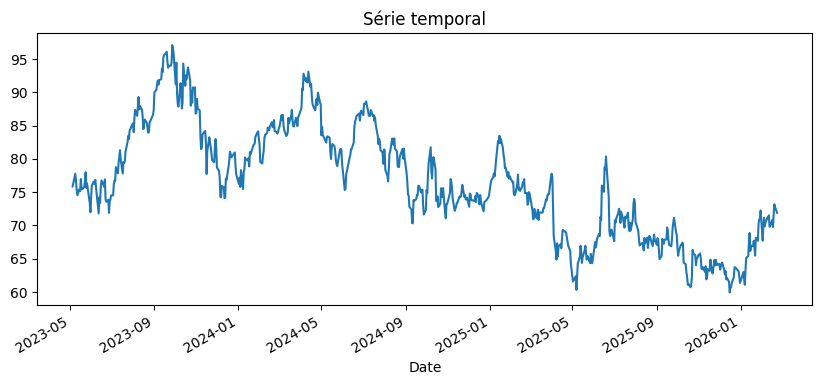

In [16]:
df['Value'].plot(figsize=(10,4))
plt.title('Série temporal')
plt.show()

# Arima Implementation

In [17]:
serie_adf = df['Value'].dropna()
serie_adf.head()

,Value
Date,
2023-05-05,75.85
2023-05-09,77.76
2023-05-10,76.70
2023-05-11,75.32
2023-05-12,74.54


In [19]:
#O teste ADF não rejeitou a hipótese nula de raiz unitária, indicando que a série apresenta comportamento não estacionário no nível

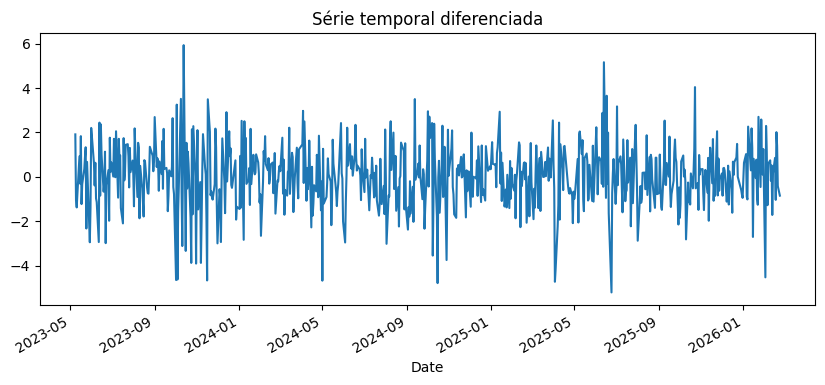

In [20]:
df['Value_diff'] = df['Value'].diff()
df.dropna(inplace=True)
df['Value_diff'].plot(figsize=(10,4))
plt.title('Série temporal diferenciada')
plt.show()

In [18]:
resultado_adf = adfuller(serie_adf)

print('ADF:', resultado_adf[0])
print('p-value:', resultado_adf[1])

ADF: -2.2562317857909235
p-value: 0.18647269352346502


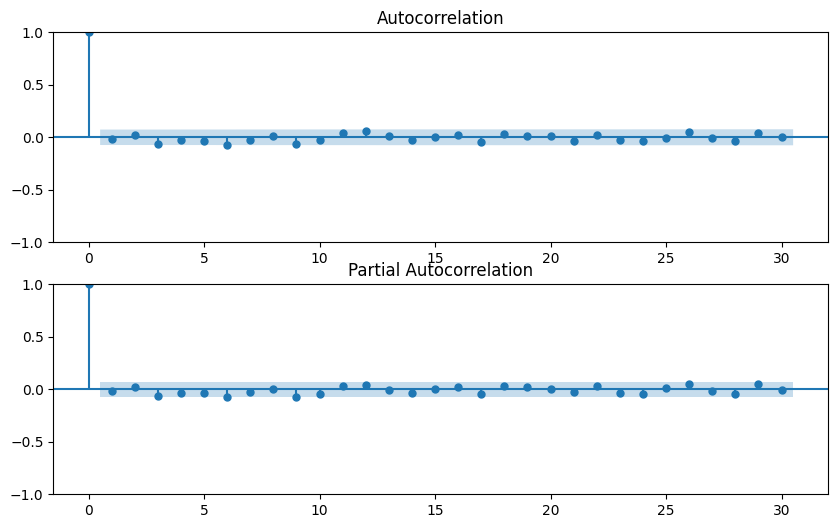

In [21]:
#O teste ADF aplicado à série diferenciada rejeita a hipótese nula de raiz unitária, indicando estacionariedade da série após uma diferenciação

#Após a aplicação da primeira diferença, o teste ADF apresentou estatística de -25.46 e p-valor inferior a 0.001, permitindo rejeitar fortemente a hipótese nula de raiz unitária.
# Dessa forma, a série tornou-se estacionária após uma diferenciação, definindo-se o parâmetro d = 1 para o modelo ARIMA


fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(df['Value_diff'], ax=ax[0], lags=30)
plot_pacf(df['Value_diff'], ax=ax[1], lags=30, method='ywm')
plt.show()

In [22]:
df.columns

Index(['Value', 'Value_diff'], dtype='object')

In [23]:
p = q = range(0, 4)
d = 1

best_aic = float("inf")
best_order = None

for i, j in itertools.product(p, q):
    try:
        model = ARIMA(df['Value'], order=(i,d,j))
        fit = model.fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = (i,d,j)
    except:
        continue

best_order, best_aic

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


((3, 1, 1), np.float64(2525.077396351051))

In [26]:
df.index


DatetimeIndex(['2023-05-09', '2023-05-10', '2023-05-11', '2023-05-12',
               '2023-05-15', '2023-05-16', '2023-05-17', '2023-05-18',
               '2023-05-19', '2023-05-22',
               ...
               '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13',
               '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19',
               '2026-02-20', '2026-02-23'],
              dtype='datetime64[ns]', name='Date', length=709, freq=None)

In [29]:
#Testando hipóteses estruturais sobre como o passado e os choques influenciam e escolher melhor ajuste.
#A dinâmica da série carrega memória direta de até 3 períodos e memória de choques de curto prazo.

model = ARIMA(df['Value'], order=(3,1,1))
fit = model.fit()
print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  709
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -1257.539
Date:                Mon, 02 Mar 2026   AIC                           2525.077
Time:                        18:09:41   BIC                           2547.890
Sample:                             0   HQIC                          2533.891
                                - 709                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7962      0.123      6.479      0.000       0.555       1.037
ar.L2          0.0306      0.040      0.767      0.443      -0.048       0.109
ar.L3         -0.0817      0.036     -2.266      0.0

In [30]:
model2 = ARIMA(df['Value'], order=(2,1,1))
fit = model.fit()
print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  709
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -1257.539
Date:                Mon, 02 Mar 2026   AIC                           2525.077
Time:                        18:10:20   BIC                           2547.890
Sample:                             0   HQIC                          2533.891
                                - 709                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7962      0.123      6.479      0.000       0.555       1.037
ar.L2          0.0306      0.040      0.767      0.443      -0.048       0.109
ar.L3         -0.0817      0.036     -2.266      0.0

In [31]:
#Embora o modelo ARIMA(3,1,1) apresente o menor AIC, ambos os modelos testados exibem resíduos não autocorrelacionados, porém heterocedásticos e não normalmente distribuídos,
#indicando que o ARIMA captura adequadamente a dinâmica média da série, mas não a estrutura de volatilidade.

n_total = len(df)
n_train = int(0.8 * n_total)

train = df.iloc[:n_train]
test  = df.iloc[n_train:]

In [32]:
train_y = train['Value']
test_y  = test['Value']


In [33]:
model = ARIMA(train_y, order=(3,1,1))
fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [60]:
forecast = fit.forecast(steps=len(test_y))
forecast.index = test_y.index

TypeError: ARCHModelFixedResult.forecast() got an unexpected keyword argument 'steps'

In [35]:
mae = mean_absolute_error(test_y, forecast)
rmse = np.sqrt(mean_squared_error(test_y, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.6509716240066865
RMSE: 5.439101603826136


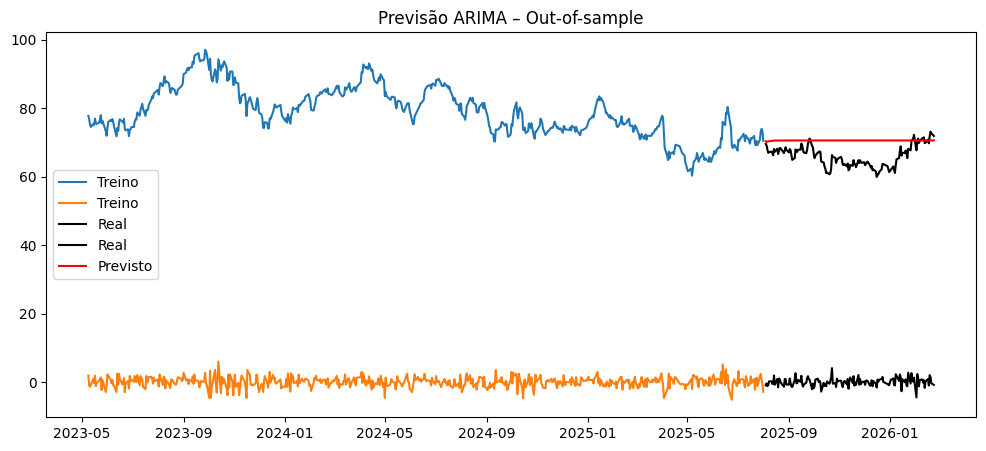

In [36]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Real', color='black')
plt.plot(forecast.index, forecast, label='Previsto', color='red')
plt.legend()
plt.title('Previsão ARIMA – Out-of-sample')
plt.show()

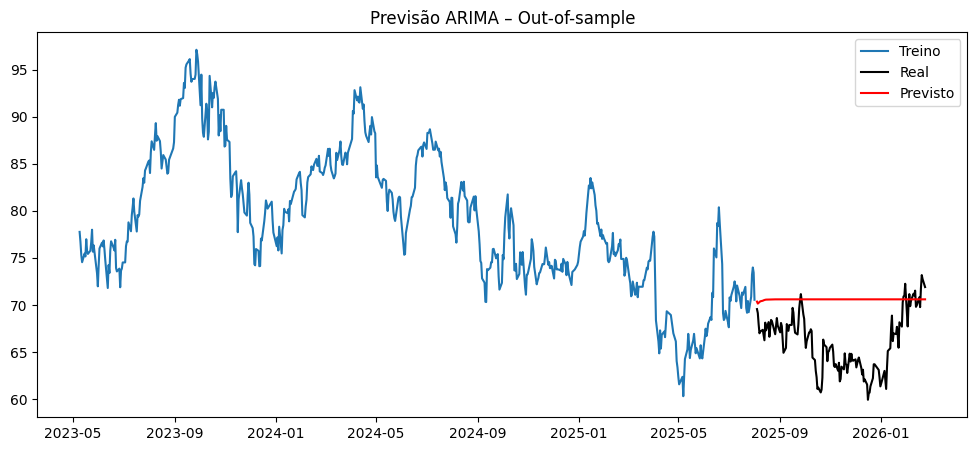

In [37]:
plt.figure(figsize=(12,5))

plt.plot(train_y.index, train_y, label='Treino')
plt.plot(test_y.index, test_y, label='Real', color='black')
plt.plot(forecast.index, forecast, label='Previsto', color='red')

plt.legend()
plt.title('Previsão ARIMA – Out-of-sample')
plt.show()

#Garch

In [43]:
# Para implementar o garch com estabilidade usaremos retornos
returns = np.log(df['Value']).diff().dropna() * 100

In [44]:
for p in range(1,4):
    for q in range(1,4):
        garchmodel = arch_model(
            returns,
            vol="Garch",
            p=p,
            q=q
        )
        res = garchmodel.fit(disp="off")
        print(p, q, res.aic)

1 1 2879.6089904119394
1 2 2881.608990083527
1 3 2883.6089900890443
2 1 2880.57511445362
2 2 2882.3216937832563
2 3 2883.841623894014
3 1 2882.575114522683
3 2 2884.3216933076546
3 3 2884.6080881428907


In [47]:
#Vencedor Garch(1,1)-> volatividade de memória curta e altamente persistente
#Bollerslev

garch = arch_model(
    returns,
    vol='Garch',
    p=1,
    q=1,
    mean='Zero'   # retornos ~ média ≈ 0
)

fit = garch.fit()

print(fit.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3224.2617642233326
Iteration:      2,   Func. Count:     12,   Neg. LLF: 105686.57761747637
Iteration:      3,   Func. Count:     17,   Neg. LLF: 1442.5703943729714
Iteration:      4,   Func. Count:     22,   Neg. LLF: 48835811.5955804
Iteration:      5,   Func. Count:     27,   Neg. LLF: 1442.0080355886885
Iteration:      6,   Func. Count:     32,   Neg. LLF: 1435.8317654335015
Iteration:      7,   Func. Count:     36,   Neg. LLF: 1435.811352716642
Iteration:      8,   Func. Count:     40,   Neg. LLF: 1435.8097826443293
Iteration:      9,   Func. Count:     44,   Neg. LLF: 1435.808475163521
Iteration:     10,   Func. Count:     48,   Neg. LLF: 1435.8084702304607
Iteration:     11,   Func. Count:     51,   Neg. LLF: 1435.8084702299163
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1435.8084702304607
            Iterations: 11
            Function evaluations: 51
            Gradient evaluat

In [53]:
forecast = fit.forecast(horizon=len(test))

vol_forecast = np.sqrt(
    forecast.variance.iloc[-1]
)

In [54]:
std_resid = fit.resid / fit.conditional_volatility

In [55]:
acorr_ljungbox(std_resid**2, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,8.709258,0.5599


In [56]:
#p-value = 05599 = alto.
#Não rejeitamos hipótese nula, não há evidencia de correlação restante

garch_forecast = fit.forecast(horizon=len(test_y))

pred_var = garch_forecast.variance.iloc[-1]
pred_vol = np.sqrt(pred_var)

In [57]:
#Tentando modelar o garch para uma comparação semelhante a de preços, para isso utilizo a melhor previsão de retorno como nula para o modelo probabilistico
pred_returns = np.zeros(len(test_y))
last_price = train_y.iloc[-1]

price_forecast = last_price * np.exp(
    np.cumsum(pred_returns)
)
price_forecast = pd.Series(
    price_forecast,
    index=test_y.index
)


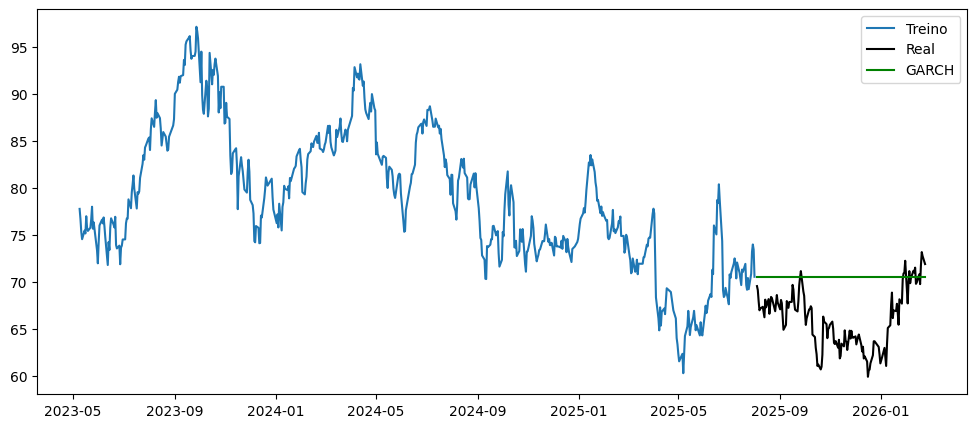

In [58]:
plt.figure(figsize=(12,5))

plt.plot(train_y.index, train_y, label="Treino")
plt.plot(test_y.index, test_y, label="Real", color="black")
plt.plot(price_forecast.index,
         price_forecast,
         label="GARCH",
         color="green")

plt.legend()
plt.show()

In [61]:
#Tentando comparar os dois modelos reconstruindo o preço com base na previsão de variancia do garch com média estimada 0
train_y = train["Value"]
test_y  = test["Value"]

#Arima
arima_model = ARIMA(train_y, order=(3,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test_y))
arima_forecast.index = test_y.index

#GarchModel

train_returns = np.log(train_y).diff().dropna() * 100

garch_model = arch_model(train_returns,
                         vol="Garch",
                         p=1,
                         q=1,
                         mean="Zero")

garch_fit = garch_model.fit(disp="off")

garch_forecast = garch_fit.forecast(horizon=len(test_y))

pred_var = garch_forecast.variance.iloc[-1].values
pred_vol = np.sqrt(pred_var)

pred_returns = np.zeros(len(test_y))

last_price = train_y.iloc[-1]

garch_price_forecast = last_price * np.exp(
    np.cumsum(pred_returns / 100)
)

garch_price_forecast = pd.Series(
    garch_price_forecast,
    index=test_y.index
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

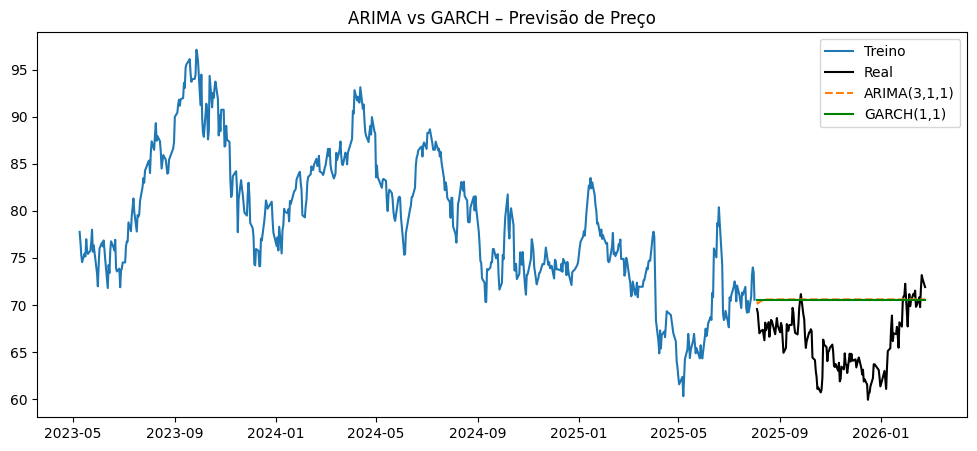

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train_y.index, train_y, label="Treino")
plt.plot(test_y.index, test_y, label="Real", color="black")

plt.plot(arima_forecast.index,
         arima_forecast,
         label="ARIMA(3,1,1)",
         linestyle="--")

plt.plot(garch_price_forecast.index,
         garch_price_forecast,
         label="GARCH(1,1)",
         color="green")

plt.legend()
plt.title("ARIMA vs GARCH – Previsão de Preço")
plt.show()

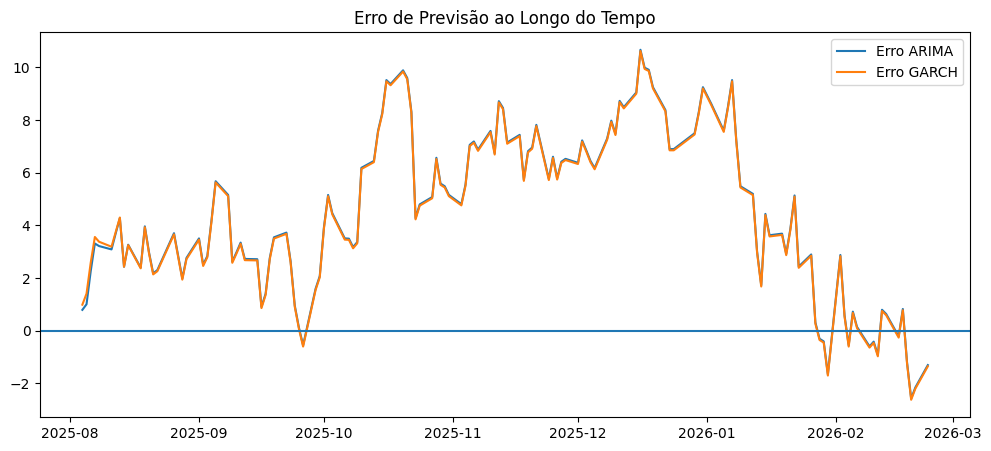

In [66]:
err_arima = arima_forecast - test_y
err_garch = garch_price_forecast - test_y

plt.figure(figsize=(12,5))
plt.plot(err_arima, label="Erro ARIMA")
plt.plot(err_garch, label="Erro GARCH")
plt.axhline(0)
plt.legend()
plt.title("Erro de Previsão ao Longo do Tempo")
plt.show()

In [68]:
mse_arima = mean_squared_error(test_y, arima_forecast)
rmse_arima = np.sqrt(mse_arima)

mse_garch = mean_squared_error(test_y, garch_price_forecast)
rmse_garch = np.sqrt(mse_garch)

print("ARIMA  - MSE:", mse_arima, "RMSE:", rmse_arima)
print("GARCH  - MSE:", mse_garch, "RMSE:", rmse_garch)

ARIMA  - MSE: 29.583826256744047 RMSE: 5.439101603826136
GARCH  - MSE: 29.23704295774646 RMSE: 5.407128901528654


In [70]:

mae_arima = np.mean(np.abs(test_y - arima_forecast))
mae_garch = np.mean(np.abs(test_y - garch_price_forecast))

print("ARIMA  - MAE:", mae_arima)
print("GARCH  - MAE:", mae_garch)

ARIMA  - MAE: 4.6509716240066865
GARCH  - MAE: 4.627112676056336


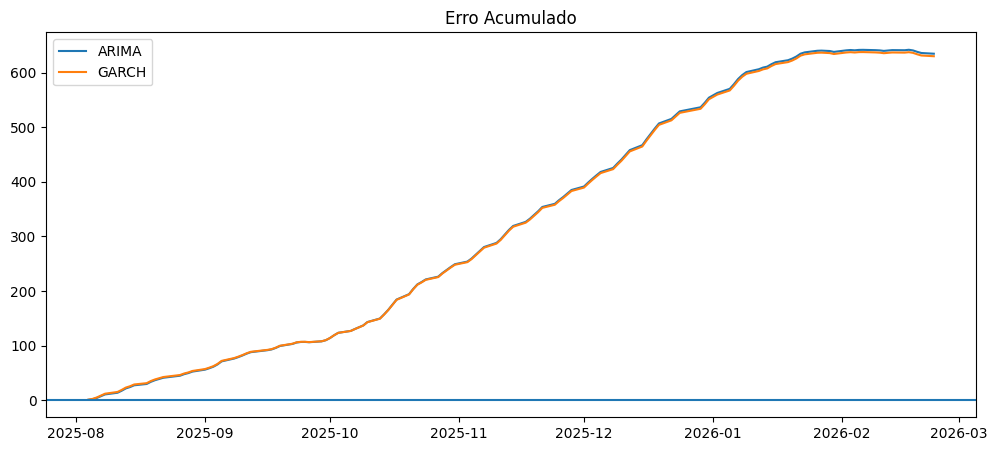

In [71]:
#Não achando diferença significativa nas predições
cum_err_arima = (arima_forecast - test_y).cumsum()
cum_err_garch = (garch_price_forecast - test_y).cumsum()

plt.figure(figsize=(12,5))
plt.plot(cum_err_arima, label="ARIMA")
plt.plot(cum_err_garch, label="GARCH")
plt.axhline(0)
plt.legend()
plt.title("Erro Acumulado")
plt.show()

#LSTM

In [97]:

n_total = len(df)
n_train = int(0.8 * n_total)

train_raw = df[['Value']].iloc[:n_train]
test_raw  = df[['Value']].iloc[n_train:]
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

In [98]:
def create_sequences(data, window=20):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 20

X_train, y_train = create_sequences(train_scaled, window)
X_test, y_test   = create_sequences(test_scaled, window)

In [99]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [100]:
model = Sequential([
    LSTM(50, activation='tanh',
         input_shape=(X_train.shape[1],1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1815
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0086
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0062
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0062
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0057
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0054
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0054
Epoch 13/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0056
Epoch 14/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0049
Epoch 15/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0053
Epoch 16/20
18/

In [101]:
pred = model.predict(X_test)

id="fixlstm1"
pred_lstm = scaler.inverse_transform(pred).flatten()
y_test_real = scaler.inverse_transform(y_test).flatten()

pred_lstm = pd.Series(
    pred_lstm,
    index=test_y.index[-len(pred_lstm):]
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [105]:
print("len(test_raw):", len(test_raw))
print("window:", window)
print("len(y_test):", len(y_test))
print("len(pred):", len(pred))

len(test_raw): 142
window: 20
len(y_test): 138
len(pred): 138


In [109]:
test_index = df.index[-len(pred_lstm):]

pred_lstm = pd.Series(pred_lstm, index=test_index)
y_true_lstm = df['Value'].iloc[-len(pred_lstm):]

In [108]:
id="chk1"
print("Real :", len(y_true_aligned))
print("ARIMA:", len(y_pred_arima))
print("GARCH:", len(y_pred_garch))
print("LSTM :", len(pred_lstm))

Real : 138
ARIMA: 138
GARCH: 138
LSTM : 122


In [111]:
y_true_aligned = test_y[-122:]
y_pred_arima = y_pred_arima[-122:]
y_pred_garch = y_pred_garch[-122:]

In [112]:
print(len(y_true_aligned),
      len(y_pred_arima),
      len(y_pred_garch),
      len(pred_lstm))

122 122 122 122


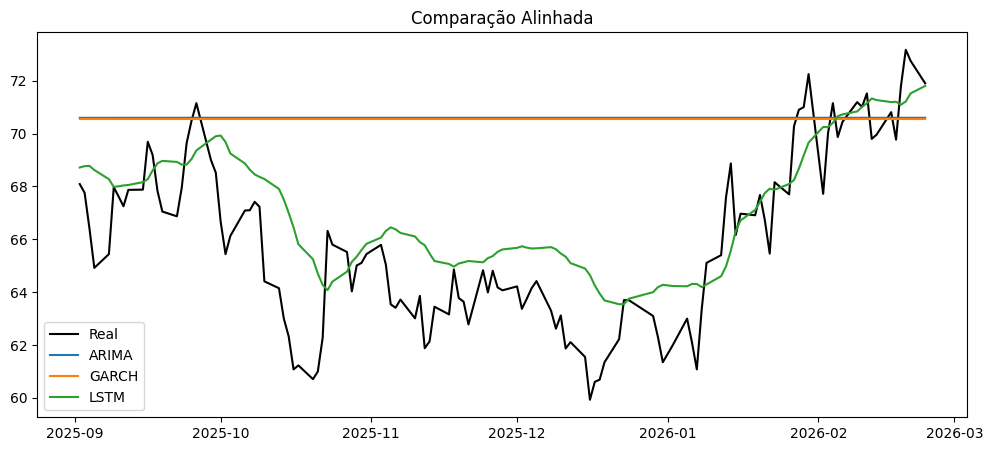

In [113]:
plt.figure(figsize=(12,5))

plt.plot(y_true_aligned, label="Real", color="black")
plt.plot(y_pred_arima, label="ARIMA")
plt.plot(y_pred_garch, label="GARCH")
plt.plot(pred_lstm, label="LSTM")

plt.legend()
plt.title("Comparação Alinhada")
plt.show()

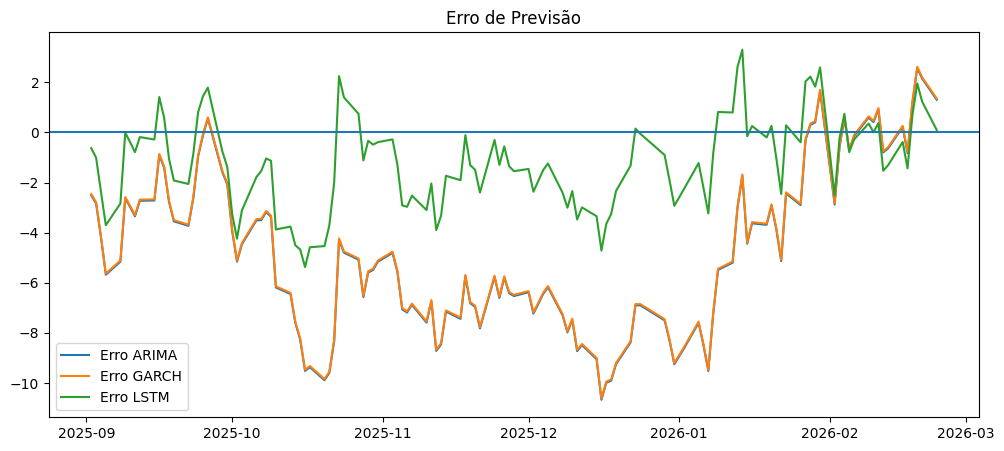

In [114]:
id="plotcmp2"
plt.figure(figsize=(12,5))

plt.plot(y_true_aligned - y_pred_arima, label="Erro ARIMA")
plt.plot(y_true_aligned - y_pred_garch, label="Erro GARCH")
plt.plot(y_true_aligned - pred_lstm, label="Erro LSTM")

plt.axhline(0)
plt.legend()
plt.title("Erro de Previsão")
plt.show()

In [117]:
mse_arima = mean_squared_error(y_true_aligned, y_pred_arima)
rmse_arima = np.sqrt(mse_arima)

mse_garch = mean_squared_error(y_true_aligned, y_pred_garch)
rmse_garch = np.sqrt(mse_garch)

mse_lstm = mean_squared_error(y_true_aligned, pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)

print("ARIMA  - MSE:", mse_arima, "RMSE:", rmse_arima)
print("GARCH  - MSE:", mse_garch, "RMSE:", rmse_garch)
print("LSTM  - MSE:", mse_lstm, "RMSE:", rmse_lstm)

ARIMA  - MSE: 33.02221626145208 RMSE: 5.746495998558781
GARCH  - MSE: 32.58180081967211 RMSE: 5.7080470232534095
LSTM  - MSE: 4.715447773933095 RMSE: 2.1715081795685447


In [118]:
mae_arima = np.mean(np.abs(y_true_aligned - y_pred_arima))
mae_garch = np.mean(np.abs(y_true_aligned - y_pred_garch))
mae_lstm = np.mean(np.abs(y_true_aligned - pred_lstm))

print("ARIMA  - MAE:", mae_arima)
print("GARCH  - MAE:", mae_garch)
print("LSTM  - MAE:", mae_lstm)

ARIMA  - MAE: 4.954650287576757
GARCH  - MAE: 4.91795081967213
LSTM  - MAE: 1.7586208531113925


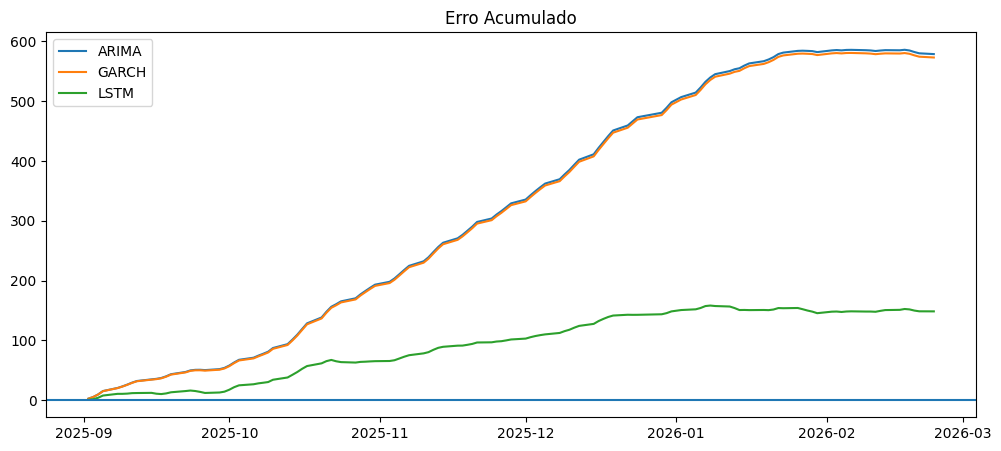

In [119]:
#Aqui achamos diferença significativa nas predições, colocando a lstm bem na frente, o resultado deve ser avaliasdo depois
cum_err_arima = (y_pred_arima - y_true_aligned).cumsum()
cum_err_garch = (y_pred_garch - y_true_aligned).cumsum()
cum_err_lstm = (pred_lstm - y_true_aligned).cumsum()

plt.figure(figsize=(12,5))
plt.plot(cum_err_arima, label="ARIMA")
plt.plot(cum_err_garch, label="GARCH")
plt.plot(cum_err_lstm, label="LSTM")
plt.axhline(0)
plt.legend()
plt.title("Erro Acumulado")
plt.show()